# Heat conduction (conductivity tree) example

## Commented Program

This example minimizes the thermal compliance of a heat-conduction problem:
distributed heat flux enters the top edge, the bottom edge is held at
`T = 0`, and the sides are insulated. The optimal layout is the classic
branching "conductivity tree" (Bendsøe & Sigmund, *Topology Optimization*,
§1.3).

In [1]:
using TopOpt

### Define the problem
`HeatTree` sets up the standard benchmark: flux `q` on the top boundary,
`T = 0` on the bottom, free left/right.

In [2]:
nels = (80, 40)
k = 1.0
q = 1.0
problem = HeatTree(Val{:Linear}, nels, (1.0, 1.0), k; q=q)

TopOpt heat conduction problem


### Parameter settings

In [3]:
V = 0.3      # volume fraction
xmin = 1e-3  # minimum density
rmin = 2.0

x0 = fill(V, TopOpt.getncells(problem))
solver = FEASolver(DirectSolver, problem; xmin=xmin, penalty=PowerPenalty(3.0))
comp = ThermalCompliance(solver)
filter = DensityFilter(solver; rmin=rmin)
obj = x -> comp(filter(PseudoDensities(x)))

#2 (generic function with 1 method)

Define volume constraint

In [4]:
volfrac = Volume(solver)
constr = x -> volfrac(filter(PseudoDensities(x))) - V
model = Model(obj)
addvar!(model, zeros(length(x0)), ones(length(x0)))
add_ineq_constraint!(model, constr)
alg = MMA87()

MMA87{GradientDescent{LineSearches.InitialPrevious{Float64}, LineSearches.HagerZhang{Float64, Base.RefValue{Bool}}, Nothing, Returns{Nothing}}}(GradientDescent{LineSearches.InitialPrevious{Float64}, LineSearches.HagerZhang{Float64, Base.RefValue{Bool}}, Nothing, Returns{Nothing}}(LineSearches.InitialPrevious{Float64}(1.0, 0.0, Inf), LineSearches.HagerZhang{Float64, Base.RefValue{Bool}}(0.1, 0.9, Inf, 5.0, 1.0e-6, 0.66, 50, 0.1, 0, Base.RefValue{Bool}(false), nothing, false), nothing, Returns{Nothing}(nothing), Flat()))

### Optimize

In [5]:
options = MMAOptions(; tol=Tolerance(; kkt=1e-4), maxiter=200)
res = optimize(model, alg, x0; options)

@show obj(res.minimizer)
@show constr(res.minimizer)

[ Info:   iter       obj      Δobj  violation  kkt_residual  
[ Info:      0   1.1e+05       Inf   0.0e+00   4.0e+02
[ Info:      1   1.1e+05   5.5e-03   0.0e+00   5.5e-03
[ Info:      2   1.1e+05   1.5e-08   0.0e+00   5.5e-03
[ Info:      3   1.1e+05   1.3e-08   0.0e+00   5.5e-03
[ Info:      4   1.1e+05   1.9e-03   0.0e+00   3.6e-03
[ Info:      5   1.1e+05   2.9e-04   0.0e+00   3.9e-03
[ Info:      6   1.1e+05   3.5e-04   0.0e+00   3.6e-03
[ Info:      7   1.1e+05   7.6e-05   0.0e+00   3.5e-03
[ Info:      8   1.1e+05   2.5e-04   0.0e+00   3.7e-03
[ Info:      9   1.1e+05   6.8e-04   0.0e+00   3.1e-03
[ Info:     10   1.1e+05   8.6e-04   0.0e+00   2.2e-03
[ Info:     11   1.1e+05   2.6e-04   0.0e+00   2.5e-03
[ Info:     12   1.1e+05   4.9e-04   0.0e+00   2.0e-03
[ Info:     13   1.1e+05   2.2e-04   0.0e+00   2.2e-03
[ Info:     14   1.1e+05   2.8e-04   0.0e+00   2.5e-03
[ Info:     15   1.1e+05   4.0e-03   0.0e+00   6.5e-03
[ Info:     16   1.1e+05   1.7e-03   0.0e+00   8.4e-03
[ I

-1.0233912409174373e-6

### (Optional) Visualize the result using Makie.jl
Need to run `using Pkg; Pkg.add("Makie")` first and either `Pkg.add("CairoMakie")` or `Pkg.add("GLMakie")`

In [6]:
using Makie
using CairoMakie

alternatively, `using GLMakie`

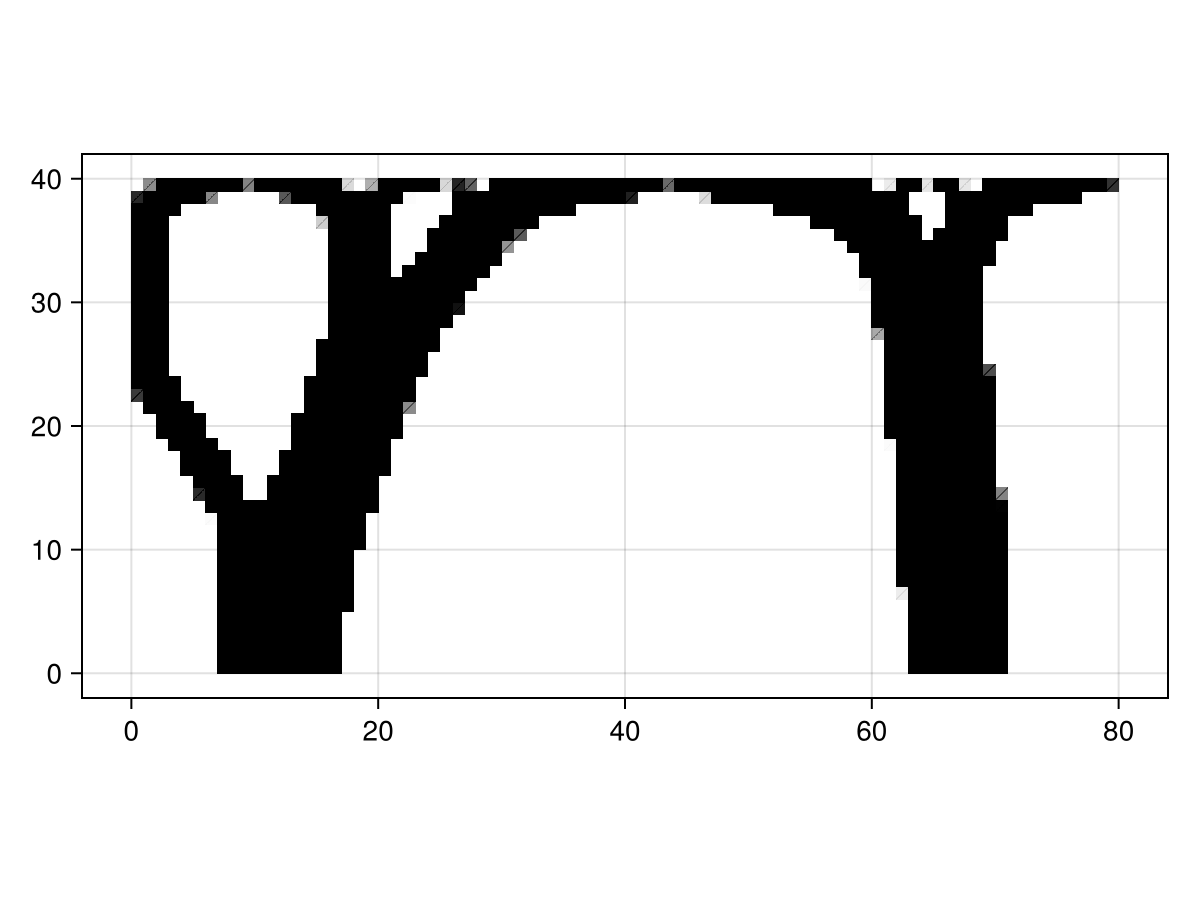

CairoMakie.Screen{IMAGE}


In [7]:
fig = visualize(problem; topology=res.minimizer)
Makie.display(fig)

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*